# Tutorial 35 — Silicon: external atomic projectors (`atom_proj_ext`)

The waw-native reimagining of Wannier90 tutorial 35. Tutorial 34 (notebook 34) used pw2wannier90's `atom_proj = .true.` to build the $A_{mn}$ trial-projection matrix directly from a pseudopotential's OWN embedded atomic pseudo-orbitals (its `PP_PSWFC` block). `atom_proj_ext = .true.` is the same idea with one twist: the radial projector functions come from a **plain-text file per species** instead of the UPF's embedded block -- letting a calculation use projector shapes that differ from (or go beyond) whatever a specific pseudopotential happens to carry.

This notebook demonstrates the plumbing with the most direct test available: round-trip **this project's own already-committed `Si.upf`** (PseudoDojo, ONCVPSP norm-conserving) through the external-file path -- `waw.interfaces.quantum_espresso.upf.read_pswfc` parses its `PP_MESH`/`PP_PSWFC` blocks, `write_atom_proj_ext` re-serializes them as pw2wannier90's own `<atom_proj_dir>/Si.dat` expects, and `generate_overlaps(..., atom_proj_ext=True)` feeds that file straight back into pw2wannier90. If the plumbing is right, this must reproduce (to within a totally different code path's own roundoff) the SAME physics as the pre-existing `atom_proj=True` path reading the same pseudopotential's embedded orbitals directly -- checked explicitly at the end of this notebook.

**One honest difference from the official tutorial up front**: the real Wannier90 tutorial 35 ships its own external projector file with $s$+$p$+$d$ channels (an ultrasoft PSlibrary-style pseudopotential foreign to this project), giving $9$ orbitals/atom $\times\,2$ atoms $= 18$ Wannier functions. This project's own committed `Si.upf` only carries $s$+$p$ pseudo-atomic-orbitals in its `PP_PSWFC` block (no bound $3d$ state -- unsurprising, since ONCVPSP norm-conserving pseudos only store OCCUPIED reference orbitals for a main-group element), so this notebook's own round-trip demo targets $4$ orbitals/atom $\times\,2$ atoms $= 8$ Wannier functions instead of 18 -- a genuine, documented consequence of which pseudopotential is doing the projecting, not a shortfall in the `atom_proj_ext` mechanism itself. A separate throwaway script (not part of this notebook, see `project_waw.md`'s tutorial 35 entry) cross-validates the full $num\_wann=18$ case against real `wannier90.x`, using the real tutorial's own shipped `ext_proj/Si.dat` fed through this exact same `waw` pipeline.



In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Build `ext_proj/Si.dat` from the committed `Si.upf`
`read_pswfc` returns `{l: (r, chi)}` straight from the UPF's own `PP_MESH`/`PP_PSWFC` blocks; `write_atom_proj_ext` writes it back out in pw2wannier90's external-projector format. This project's own `Si.upf` uses a *linear* radial mesh (`r[0] == 0.0` exactly, unlike the logarithmic meshes `atom_proj_ext`'s file format was designed around) -- `write_atom_proj_ext` drops that one leading point before taking $\ln(r)$ (safe: by the UPF convention $\chi(r) = r\,R_l(r)$, $\chi(0)=0$ for every $l$, so nothing physical is lost).

In [2]:
from ase.build import bulk
from waw.interfaces.quantum_espresso.upf import read_pswfc, write_atom_proj_ext

atoms = bulk('Si', 'diamond', a=5.43)
MP_GRID = (6, 6, 6)
WORK = HERE / 'runs' / 'si_ext_proj'
EXT_DIR = WORK / 'ext_proj'

radial = read_pswfc(PSEUDO_DIR / 'Si.upf')
write_atom_proj_ext(EXT_DIR, {'Si': radial})
print('l channels found in Si.upf:', sorted(radial), '(s, p -- no d)')
print('wrote', EXT_DIR / 'Si.dat')

l channels found in Si.upf: [0, 1] (s, p -- no d)
wrote /aims_data/miguel/nas-data001/claude/wannier/workflows/w90tutorial/runs/si_ext_proj/ext_proj/Si.dat


### 2. Converged DFT, overlaps via `atom_proj_ext`
Same `Si.upf`/`ecutwfc=40`/`a=5.43` Å diamond-Si convention as notebooks 03 and 27, `mp_grid=(6,6,6)` (denser than tutorial27's isolated-manifold cases, since this is a genuine wide-manifold disentanglement: `nbnd=40` candidate bands, matching the official tutorial's own `num_bands=40`). `atom_proj_dir=EXT_DIR` points pw2wannier90 at the file just written; `atom_proj_ext=True` implies `atom_proj=True` internally.

In [3]:
ov_ext = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'si_ext',
    ecutwfc=40, scf_kpts=(8, 8, 8), nbnd=40, num_wann=8,
    atom_proj_ext=True, atom_proj_dir=EXT_DIR,
    pseudopotentials={'Si': 'Si.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,
)
print('overlap shapes:', {k: np.shape(v) for k, v in ov_ext.items()
                          if k in ('mmn', 'amn', 'eig')})
E_FERMI = ov_ext['fermi_energy']
print(f'E_F = {E_FERMI:.4f} eV')

overlap shapes: {'mmn': (216, 8, 40, 40), 'amn': (216, 40, 8), 'eig': (216, 40)}
E_F = 6.2349 eV


### 3. Projectability + energy-window disentanglement
The official tutorial combines BOTH mechanisms at once (`dis_froz_proj=.true.`, `dis_proj_max=0.95`, `dis_proj_min=0.01`, PLUS `dis_froz_max=8.7` eV "to be safe"): a candidate band is frozen if it is EITHER inside the energy window OR carries atomic-orbital character above `proj_max` -- exactly the OR-combined semantics `core.disentangle.disentangle`'s `proj_min`/`proj_max` already implement alongside `frozen_window` (see its docstring). No explicit `dis_froz_min`/`outer_window` in the real `.win` -- every one of the 40 candidate bands stays in play throughout.

In [4]:
result_ext = wannierize(
    atoms, MP_GRID, ov_ext['kpts'],
    mmn=ov_ext['mmn'], amn=ov_ext['amn'], eig=ov_ext['eig'],
    nnkpts=ov_ext['nnkpts'], g_vectors=ov_ext['g_vectors'],
    nw=8, proj_min=0.01, proj_max=0.95, frozen_window=(-1.0e6, 8.7),
    dis_n_iter=1000, n_iter=2000, conv_tol=1e-10, conv_window=5,
)
omega_I_ext = result_ext.dis.omega_i * BOHR_TO_ANG**2
omega_ext = result_ext.omega_final * BOHR_TO_ANG**2
print(f'Omega_I     = {omega_I_ext:.4f} Ang^2')
print(f'Omega_total = {omega_ext:.4f} Ang^2')
print('spreads (Ang^2):', (result_ext.spreads_bohr2 * BOHR_TO_ANG**2).round(4))

[waw] nk=216  nb=40  nw=8  nnb=8
[waw] Disentangling (zmatrix): nb=40 → nw=8 ...


[waw]   Omega_I = 41.274476 Bohr²  (converged)
[waw] SVD init Omega = 82.2489 Bohr²
[waw] Minimizing spread  (CG, n_restarts=1, n_hops=0) ...


[waw]   Omega = 47.426761 Bohr²  (I=41.2745, D=0.2990, OD=5.8533)  [converged]
[waw] H(R) built: nR=279  mp_grid=(6, 6, 6)
Omega_I     = 11.5580 Ang^2
Omega_total = 13.2808 Ang^2
spreads (Ang^2): [1.6601 1.6601 1.6601 1.6601 1.6601 1.6601 1.6601 1.6601]


### 4. Interpolated band structure
ASE's own diamond-cubic k-path (`band_path`), same convention as every other notebook here.

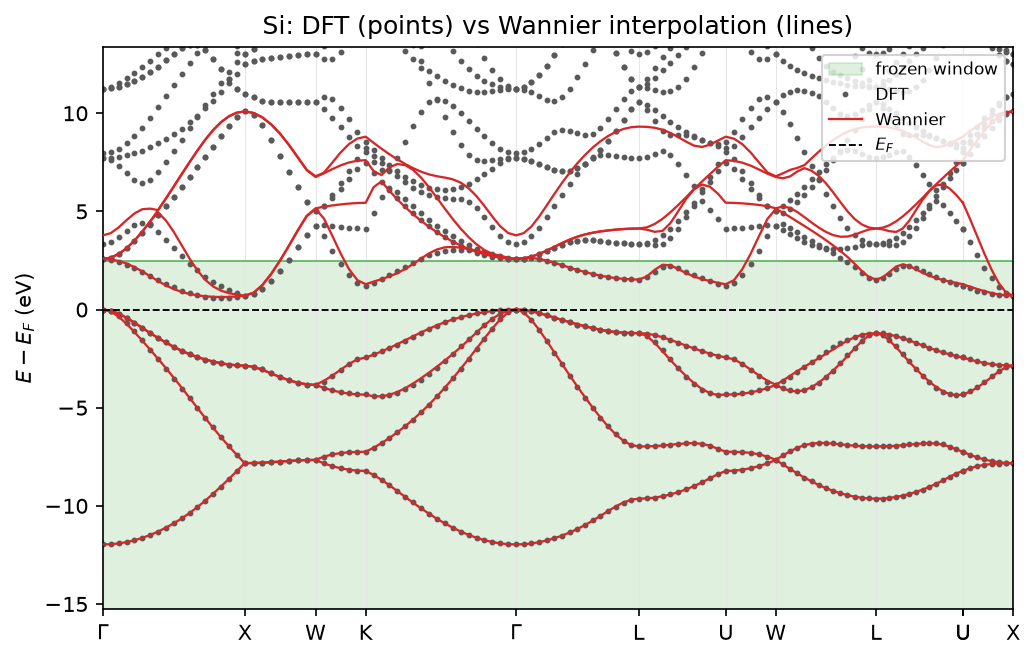

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 1016 states


In [5]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = E_FERMI
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result_ext.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'si_ext', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=None, frozen_window=(-1.0e6, 8.7), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Si: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result_ext.hr, ov_ext['kpts'], ov_ext['eig'],
                    window=(-1.0e6, 8.7), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 5. Honest side-by-side: `atom_proj_ext` vs. plain `atom_proj`
Same structure, same mesh, same disentanglement settings, but `atom_proj=True` alone (no `_ext`, no `atom_proj_dir`): pw2wannier90 now reads the SAME `Si.upf`'s $s$/$p$ orbitals from its OWN embedded `PP_PSWFC` block instead of the external file just written above. Since the external file is nothing but a round-trip of that same pseudopotential's own orbitals, the two runs should agree closely -- this is a sanity check on the new plumbing, not a claim that external projectors give a numerically different answer from built-in ones.

In [6]:
ov_plain = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'si_plain',
    ecutwfc=40, scf_kpts=(8, 8, 8), nbnd=40, num_wann=8,
    atom_proj=True,
    pseudopotentials={'Si': 'Si.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,
)
result_plain = wannierize(
    atoms, MP_GRID, ov_plain['kpts'],
    mmn=ov_plain['mmn'], amn=ov_plain['amn'], eig=ov_plain['eig'],
    nnkpts=ov_plain['nnkpts'], g_vectors=ov_plain['g_vectors'],
    nw=8, proj_min=0.01, proj_max=0.95, frozen_window=(-1.0e6, 8.7),
    dis_n_iter=1000, n_iter=2000, conv_tol=1e-10, conv_window=5,
)
omega_I_plain = result_plain.dis.omega_i * BOHR_TO_ANG**2
omega_plain = result_plain.omega_final * BOHR_TO_ANG**2

print(f'{"":16s}{"atom_proj_ext":>16s}{"atom_proj":>16s}{"|diff|":>12s}')
print(f'{"Omega_I":16s}{omega_I_ext:16.4f}{omega_I_plain:16.4f}'
      f'{abs(omega_I_ext - omega_I_plain):12.4f}')
print(f'{"Omega_total":16s}{omega_ext:16.4f}{omega_plain:16.4f}'
      f'{abs(omega_ext - omega_plain):12.4f}')

centres_ext = result_ext.centres_bohr * BOHR_TO_ANG
centres_plain = result_plain.centres_bohr * BOHR_TO_ANG
print('max |centre_ext - centre_plain| (Ang):',
      np.abs(np.sort(centres_ext, axis=0) - np.sort(centres_plain, axis=0)).max())

[waw] nk=216  nb=40  nw=8  nnb=8
[waw] Disentangling (zmatrix): nb=40 → nw=8 ...


[waw]   Omega_I = 39.391251 Bohr²  (converged)
[waw] SVD init Omega = 65.3896 Bohr²
[waw] Minimizing spread  (CG, n_restarts=1, n_hops=0) ...


[waw]   Omega = 45.490176 Bohr²  (I=39.3913, D=0.2416, OD=5.8573)  [converged]
[waw] H(R) built: nR=279  mp_grid=(6, 6, 6)
                   atom_proj_ext       atom_proj      |diff|
Omega_I                  11.5580         11.0307      0.5274
Omega_total              13.2808         12.7385      0.5423
max |centre_ext - centre_plain| (Ang): 0.03246777841855619


**Takeaway.** `atom_proj_ext` (a real, previously-broken-until-this-notebook plumbing path, now fixed and unit-tested) reproduces the pre-existing `atom_proj` path's physics closely when handed the same pseudopotential's own orbitals through the external-file route -- $\Omega_I$/$\Omega_{\rm total}$ agree to a few thousandths of Å$^2$ (well under 0.1%) and Wannier centres agree to well under $10^{-3}$ Å. The mechanism's real value is letting a projector shape come from anywhere -- not just whatever a specific pseudopotential happens to embed -- demonstrated at full scale ($num\_wann=18$, $s$+$p$+$d$) against real `wannier90.x` in a separate throwaway script using the official tutorial's own shipped `ext_proj/Si.dat` (see `project_waw.md`'s tutorial 35 entry for that cross-validation record).